In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "util").is_dir():
    ROOT = ROOT.parent
if not (ROOT / "util").is_dir():
    ROOT = ROOT.parent
sys.path.append(str(ROOT))

import importlib

from util import config
import util.test_data_loader as tdl
import util.utilities as util

# Reload config first (paths live here)
importlib.reload(config)

# Reload utilities so they see the updated config
importlib.reload(util)
importlib.reload(tdl)
DataLoader = tdl.DataLoader

import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt


In [5]:


# -----------------------------
# Helpers (kept at module level)
# -----------------------------
KEYS = ["sub", "id", "date", "ses", "trial_id", "trial_type", "trial_type_day"]
NUMERIC_KEYS = ["sub", "ses", "trial_id", "trial_type_day"]
STRING_KEYS = ["id", "date", "trial_type"]
OVERWRITE_COLS = ["usable", "trial note"]

def _to_int_nullable(s: pd.Series) -> pd.Series:
    """Coerce to pandas nullable Int64 (keeps NA as <NA>)."""
    return pd.to_numeric(s, errors="coerce").astype("Int64")

def _ensure_keys(df: pd.DataFrame) -> pd.DataFrame:
    """Ensure all key columns exist, with normalized dtypes."""
    df = df.copy()
    for k in KEYS:
        if k not in df.columns:
            df[k] = pd.NA
    for c in NUMERIC_KEYS:
        df[c] = _to_int_nullable(df[c])
    for c in STRING_KEYS:
        df[c] = df[c].astype("string")
    return df

def _key_index(df: pd.DataFrame) -> pd.MultiIndex:
    return pd.MultiIndex.from_frame(df[KEYS])

def _normalize_animal_info(animal_info: pd.DataFrame) -> pd.DataFrame:
    animal_info = animal_info.copy()
    if "sub" in animal_info.columns:
        animal_info["sub"] = _to_int_nullable(animal_info["sub"])
    if "id" in animal_info.columns:
        animal_info["id"] = animal_info["id"].astype("string")
    return animal_info

def _normalize_ephys(ephys_info: pd.DataFrame) -> pd.DataFrame:
    ephys = _ensure_keys(ephys_info)

    if "ephys_trial_id" not in ephys.columns:
        ephys["ephys_trial_id"] = pd.NA
    if "ephys_usable" not in ephys.columns:
        ephys["ephys_usable"] = pd.NA

    ephys["ephys_trial_id"] = _to_int_nullable(ephys["ephys_trial_id"])
    ephys["ephys_usable"] = _to_int_nullable(ephys["ephys_usable"])

    if "usable" in ephys.columns:
        ephys["usable"] = _to_int_nullable(ephys["usable"])
    if "trial note" in ephys.columns:
        ephys["trial note"] = ephys["trial note"].astype("string")
    return ephys

def _merge_ephys(meta: pd.DataFrame, ephys: pd.DataFrame) -> pd.DataFrame:
    bring = []
    if "ephys_trial_id" in ephys.columns:
        bring.append("ephys_trial_id")
    if "ephys_usable" in ephys.columns:
        bring.append("ephys_usable")

    overwrite_cols = []
    for c in OVERWRITE_COLS:
        if c in meta.columns and c in ephys.columns:
            overwrite_cols.append(c)
            bring.append(c)

    ephys_merge = ephys[KEYS + bring].copy()
    merged = meta.merge(ephys_merge, on=KEYS, how="left", suffixes=("", "_ephys"))

    for c in overwrite_cols:
        c_e = f"{c}_ephys"
        if c_e in merged.columns:
            use_e = merged[c_e].notna() & (merged[c_e] != merged[c])
            merged.loc[use_e, c] = merged.loc[use_e, c_e]
            merged = merged.drop(columns=[c_e])

    if "usable" in merged.columns:
        merged["usable"] = _to_int_nullable(merged["usable"])
    if "ephys_trial_id" in merged.columns:
        merged["ephys_trial_id"] = _to_int_nullable(merged["ephys_trial_id"])
    if "ephys_usable" in merged.columns:
        merged["ephys_usable"] = _to_int_nullable(merged["ephys_usable"])
    return merged

def _append_ephys_only(merged: pd.DataFrame, meta: pd.DataFrame, ephys: pd.DataFrame, animal_info: pd.DataFrame) -> pd.DataFrame:
    base_keys_idx = _key_index(meta.drop_duplicates(KEYS))
    ephys_keys_idx = _key_index(ephys.drop_duplicates(KEYS))
    is_new = ~ephys_keys_idx.isin(base_keys_idx)
    if not np.any(is_new):
        return merged

    ephys_only = ephys.loc[is_new].copy()
    ephys_only = ephys_only.drop_duplicates(subset=KEYS, keep="first")
    ephys_only = ephys_only.merge(animal_info, on=["sub", "id"], how="left", suffixes=("", "_animal"))

    for col in merged.columns:
        if col not in ephys_only.columns:
            ephys_only[col] = pd.NA
    for col in ephys_only.columns:
        if col not in merged.columns:
            merged[col] = pd.NA

    ephys_only = ephys_only[merged.columns]
    return pd.concat([merged, ephys_only], ignore_index=True)

def load_metadata(type: str = "combined") -> pd.DataFrame:
    """
    Read metadata files and optionally combine trials + animals + ephys.

    ephys merge rules:
      - merge on keys: ['sub','id','date','ses','trial_id','trial_type','trial_type_day']
      - add ephys_info columns: ephys_trial_id, ephys_usable
      - overwrite meta['usable'] and meta['trial note'] using ephys values when they differ (and ephys is non-null)
      - append ephys-only rows (keys present in ephys but not in meta)
    """
    animal_info = pd.read_csv(config.animal_info_path)
    trial_info = pd.read_csv(config.trial_info_path)
    ephys_info = pd.read_csv(config.ephys_info_path)

    if type == "animals":
        return animal_info
    if type == "trials":
        return trial_info
    if type == "ephys":
        return ephys_info
    if type != "combined":
        raise ValueError("type must be one of: 'combined', 'animals', 'trials', 'ephys'")

    trial_info_n = _ensure_keys(trial_info)
    animal_info_n = _normalize_animal_info(animal_info)
    meta = trial_info_n.merge(animal_info_n, on=["sub", "id"], how="left")

    if "usable" in meta.columns:
        meta["usable"] = _to_int_nullable(meta["usable"])
    if "trial note" in meta.columns:
        meta["trial note"] = meta["trial note"].astype("string")

    ephys = _normalize_ephys(ephys_info)
    merged = _merge_ephys(meta, ephys)
    merged = _append_ephys_only(merged, meta, ephys, animal_info_n)

    merged = merged.sort_values(by=KEYS, kind="mergesort").reset_index(drop=True)
    return merged

In [11]:
metadata = load_metadata("combined")
dl = DataLoader(metadata.iloc[1395])
position = dl.get_data('position')
cheeseboardMap = util.load_cheeseboard_map()
triggerLoc = dl.get_data('triggerLoc')
img = dl.get_data('trace')

In [73]:
metadata

,sub,id,date,ses,trial_id,trial_type,trial_type_day,test_type,usable,trial_note,genotype,test_order,remapping,short_duration,LFP,animal_note,ephys_trial_id,ephys_usable
0,1,A,20241205,1,1,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN,<NA>,<NA>
1,1,A,20241205,1,2,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN,<NA>,<NA>
2,1,A,20241205,1,3,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN,<NA>,<NA>
3,1,A,20241205,1,4,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN,<NA>,<NA>
4,1,A,20241205,1,5,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5986,63,BR,20251223,8,5,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN,<NA>,<NA>
5987,63,BR,20251223,8,6,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN,<NA>,<NA>
5988,63,BR,20251223,8,7,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN,<NA>,<NA>
5989,63,BR,20251223,8,8,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN,<NA>,<NA>


In [12]:
meta_ephys = metadata[
    (metadata['id'].isin(['AM', 'AN','AO'])) ]

meta_ephys

,sub,id,date,ses,trial_id,trial_type,trial_type_day,test_type,usable,trial_note,genotype,test_order,remapping,short_duration,LFP,animal_note,ephys_trial_id,ephys_usable
1507,16,AM,20250725,1,1,H,1,NaN,1,NaN,ChR2,ef,1,0,1,"experiment repeated for this animal, first rou...",0,0
1508,16,AM,20250725,1,2,H,1,NaN,1,NaN,ChR2,ef,1,0,1,"experiment repeated for this animal, first rou...",0,0
1509,16,AM,20250725,1,3,H,1,NaN,1,NaN,ChR2,ef,1,0,1,"experiment repeated for this animal, first rou...",0,0
1510,16,AM,20250725,1,4,H,1,NaN,1,NaN,ChR2,ef,1,0,1,"experiment repeated for this animal, first rou...",0,0
1511,16,AM,20250725,1,5,H,1,NaN,1,NaN,ChR2,ef,1,0,1,"experiment repeated for this animal, first rou...",0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3147,18,AO,20251011,47,11,T,1,NaN,1,NaN,ChR2,fe,1,0,1,"experiment repeated for this animal, first rou...",19,1
3148,18,AO,20251012,48,0,B,1,NaN,1,NaN,ChR2,fe,1,0,1,"experiment repeated for this animal, first rou...",1,1
3149,18,AO,20251012,48,1,T,1,NaN,0,NaN,ChR2,fe,1,0,1,"experiment repeated for this animal, first rou...",2,0
3150,18,AO,20251012,48,2,B,1,NaN,1,NaN,ChR2,fe,1,0,1,"experiment repeated for this animal, first rou...",4,1


In [69]:
# First inside_roi time per trial (preprocessed position)
def _normalize_inside_roi(series):
    if series.dtype == bool:
        return series.values.astype(bool)
    return series.astype(str).str.upper().isin(["TRUE", "1", "T", "YES"]).values.astype(bool)

def _first_true_time(t_s, mask):
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0 or not mask.any():
        return np.nan
    return float(np.asarray(t_s, dtype=float)[np.where(mask)[0][0]])

meta_subset = metadata[metadata["id"].isin(["AM", "AN", "AO"])].reset_index(drop=True)
rows = []
for idx in tqdm(range(len(meta_subset))):
    row = meta_subset.iloc[idx]
    rec = {k: (row[k] if k in meta_subset.columns else pd.NA) for k in KEYS}
    rec["row_idx"] = idx
    try:
        dl = DataLoader(metadata_ses=row)
        pos = dl.get_data("position")
    except Exception:
        rec["first_inside_s"] = np.nan
        rows.append(rec)
        continue

    if pos is None or len(pos) == 0:
        rec["first_inside_s"] = np.nan
        rows.append(rec)
        continue

    pos = pos.copy()
    pos["inside_roi"] = _normalize_inside_roi(pos["inside_roi"])
    t = pos["t"].astype(float).values
    dt = float(np.nanmedian(np.diff(t))) if t.size > 1 else np.nan
    if np.isfinite(dt) and dt > 1.0:
        t = t / 1000.0
    rec["first_inside_s"] = _first_true_time(t, pos["inside_roi"].values)
    rows.append(rec)

df_first_inside = pd.DataFrame(rows)
df_first_inside["lt_3s"] = df_first_inside["first_inside_s"] < 3
df_first_inside

  2%|▏         | 41/1645 [00:00<00:10, 147.59it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-016_id-AM/ses-03_date-20250727/behav/sub-016_ses-03_trial-00_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-016_id-AM/ses-04_date-20250728/behav/sub-016_ses-04_trial-00_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-016_id-AM/ses-05_date-20250729/behav/sub-016_ses-05_trial-00_data-position.csv' does not exist.


  5%|▌         | 86/1645 [00:00<00:08, 192.29it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-016_id-AM/ses-06_date-20250730/behav/sub-016_ses-06_trial-00_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-016_id-AM/ses-07_date-20250731/behav/sub-016_ses-07_trial-00_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-016_id-AM/ses-08_date-20250801/behav/sub-016_ses-08_trial-00_data-position.csv' does not exist.


 10%|▉         | 161/1645 [00:00<00:06, 231.82it/s]

...

 96%|█████████▋| 1584/1645 [00:07<00:00, 236.05it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-018_id-AO/ses-44_date-20251008/behav/sub-018_ses-44_trial-00_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-018_id-AO/ses-45_date-20251009/behav/sub-018_ses-45_trial-00_data-position.csv' does not exist.


100%|██████████| 1645/1645 [00:07<00:00, 210.69it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-018_id-AO/ses-46_date-20251010/behav/sub-018_ses-46_trial-00_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-018_id-AO/ses-47_date-20251011/behav/sub-018_ses-47_trial-00_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-018_id-AO/ses-47_date-20251011/behav/sub-018_ses-47_trial-10_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-018_id-AO/ses-48_date-20251012/behav/sub-018_ses-48_trial-00_data-position.csv' does not exist.


,sub,id,date,ses,trial_id,trial_type,trial_type_day,row_idx,first_inside_s,lt_3s
0,16,AM,20250725,1,1,H,1,0,4.249,False
1,16,AM,20250725,1,2,H,1,1,2.658,True
2,16,AM,20250725,1,3,H,1,2,17.061,False
3,16,AM,20250725,1,4,H,1,3,17.415,False
4,16,AM,20250725,1,5,H,1,4,3.709,False
...,...,...,...,...,...,...,...,...,...,...
1640,18,AO,20251011,47,11,T,1,1640,22.407,False
1641,18,AO,20251012,48,0,B,1,1641,NaN,False
1642,18,AO,20251012,48,1,T,1,1642,14.666,False
1643,18,AO,20251012,48,2,B,1,1643,25.612,False


In [76]:
# test if the dataloader works for generating path
for rowIdx in range(len(meta_ephys)):
    dl = DataLoader(metadata_ses=meta_ephys.iloc[rowIdx])
    if hasattr(dl, "generate_preprocess_ephys_filepath"):
        try:
            print(dl.generate_preprocess_ephys_filepath())
        except ValueError:
            pass  # no ephys for this trial

/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-016_id-AM/ses-03_date-20250727/ephys/sub-016_ses-03_trial-01_ephys
/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-016_id-AM/ses-03_date-20250727/ephys/sub-016_ses-03_trial-03_ephys
/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-016_id-AM/ses-03_date-20250727/ephys/sub-016_ses-03_trial-02_ephys
/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-016_id-AM/ses-03_date-20250727/ephys/sub-016_ses-03_trial-05_ephys
/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-016_id-AM/ses-03_date-20250727/ephys/sub-016_ses-03_trial-04_ephys
/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-016_id-AM/ses-03_date-20250727/ephys/sub-016_ses-03_trial-07_ephys
/Users/stella/Desktop/PhD/paulsen_lab/An

In [18]:
# rename ephys folders

from pathlib import Path
import re

raw_root = Path("/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/rawdata")
animals = ["sub-016_id-AM", "sub-017_id-AN", "sub-018_id-AO"]
rec_re = re.compile(r"recording(\d+)$")

for animal in animals:
    animal_root = raw_root / animal
    if not animal_root.is_dir():
        continue
    sub = animal.split("_id-")[0]  # sub-016
    for ses_dir in animal_root.iterdir():
        if not ses_dir.is_dir():
            continue
        if not ses_dir.name.startswith("ses-"):
            continue
        ses = ses_dir.name.split("_", 1)[0]  # ses-03
        ephys_dir = ses_dir / "ephys"
        if not ephys_dir.is_dir():
            continue
        for rec_dir in ephys_dir.iterdir():
            if not rec_dir.is_dir():
                continue
            m = rec_re.match(rec_dir.name)
            if not m:
                continue
            trial_num = int(m.group(1))
            new_name = f"{sub}_{ses}_trial-{trial_num:02d}_ephys"
            target = ephys_dir / new_name
            if target.exists():
                continue
            rec_dir.rename(target)

print("Done")

Done


In [63]:
# check if the name generated by new dataloader correspond with the naming

meta_ephys = metadata[metadata["id"].isin(["AM", "AN", "AO"])].reset_index(drop=True)

missing = []
for rowIdx in range(len(meta_ephys)):
    dl = DataLoader(metadata_ses=meta_ephys.iloc[rowIdx])
    if not hasattr(dl, "generate_ephys_filepath"):
        continue
    try:
        p = Path(dl.generate_ephys_filepath())
    except ValueError:
        continue  # no ephys for this trial
    if not p.is_dir():
        missing.append(str(p))

print("Missing ephys folders:", len(missing))
for p in missing:
    print("WARNING:", p)

Missing ephys folders: 0


In [87]:
# Rename Acquisition_Board-* stream folders to Acquisition_Board-100.Rhythm Data across meta_ephys (rawdata only)
from pathlib import Path

TARGET_STREAM = "Acquisition_Board-100.Rhythm Data"
dry_run = False  # set to False to apply renames

meta_ephys = metadata[metadata["id"].isin(["AM", "AN", "AO"])].reset_index(drop=True)

changed = []
conflicts = []
missing = []

for rowIdx in range(len(meta_ephys)):
    row = meta_ephys.iloc[rowIdx]
    dl = DataLoader(metadata_ses=row)

    rec = None
    if hasattr(dl, "generate_ephys_filepath"):
        try:
            rec = Path(dl.generate_ephys_filepath())
        except Exception:
            rec = None

    if rec is None or not rec.is_dir():
        # Fallback to trial_id-based folder name
        rec = Path(config.data_path) / "rawdata" / dl.sub_dir / dl.ses_dir / "ephys" / f"{dl.filename_init}_ephys"
        if not rec.is_dir():
            missing.append(str(rec))
            continue

    cont_root = rec / "continuous"
    evt_root = rec / "events"
    if not cont_root.is_dir():
        missing.append(str(cont_root))
        continue

    stream_dirs = [p for p in cont_root.iterdir() if p.is_dir() and p.name.startswith("Acquisition_Board-") and p.name.endswith(".Rhythm Data")]
    for stream_dir in stream_dirs:
        if stream_dir.name == TARGET_STREAM:
            continue
        target_dir = cont_root / TARGET_STREAM
        if target_dir.exists():
            conflicts.append((str(stream_dir), str(target_dir)))
            continue

        # Rename continuous stream folder
        if not dry_run:
            stream_dir.rename(target_dir)
        changed.append((str(stream_dir), str(target_dir)))

        # Rename matching events folder if present
        evt_src = evt_root / stream_dir.name
        evt_dst = evt_root / TARGET_STREAM
        if evt_src.exists():
            if evt_dst.exists():
                conflicts.append((str(evt_src), str(evt_dst)))
            else:
                if not dry_run:
                    evt_src.rename(evt_dst)
                changed.append((str(evt_src), str(evt_dst)))

print("Dry run:", dry_run)
print("Renamed:", len(changed))
print("Conflicts:", len(conflicts))
print("Missing:", len(missing))
for src, dst in changed:
    print("RENAME:", src, "->", dst)
for src, dst in conflicts:
    print("CONFLICT:", src, "->", dst)
for p in missing[:10]:
    print("MISSING:", p)

Dry run: False
Renamed: 222
Conflicts: 0
Missing: 346
RENAME: /Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/rawdata/sub-016_id-AM/ses-03_date-20250727/ephys/sub-016_ses-03_trial-01_ephys/continuous/Acquisition_Board-102.Rhythm Data -> /Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/rawdata/sub-016_id-AM/ses-03_date-20250727/ephys/sub-016_ses-03_trial-01_ephys/continuous/Acquisition_Board-100.Rhythm Data
RENAME: /Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/rawdata/sub-016_id-AM/ses-03_date-20250727/ephys/sub-016_ses-03_trial-01_ephys/events/Acquisition_Board-102.Rhythm Data -> /Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/rawdata/sub-016_id-AM/ses-03_date-20250727/ephys/sub-016_ses-03_trial-01_ephys/events/Acquisition_Board-100.Rhythm Data
RENAME: /Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/rawdata/sub-016_id-AM/ses-03_date-20250727/

1. downsample the ephys trace to 1000 Hz (optional)
2. Load and apply TTL signals onto ephys timescale. If no TTL detected, print it and just save the file. 
3. Must keep and not change the ‘preprocess_position’ function. 
4. If TTL detected, align the ephys trace by aligning the onset of first TTL with when ‘inside_roi’ become TRUE for the first time for that trial in the processed position file. 
5. Once aligned, backtrack from where the first TRUE ‘inside_roi’ happens to the beginning of trial where ‘t’ = 0 (in preprocessed position file), remove the part of ephys trace that happened before the beginning of trial and reset the timestamp so that time of ephys also starts from zero, just as the same timeline for preprocessed position file. Save the preprocessed ephys. 
6. Remember that position file ‘t’ is in unit of millisecond, ephys time unit is in second, there need to be a conversion.

when trial type = B, no need to align with position file, skips alignment and only saves the downsampled LFP plus the alignment JSON

In [21]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.widgets import Slider
from scipy import signal

# If in Jupyter, this backend is usually needed for a working Slider
try:
    get_ipython().run_line_magic("matplotlib", "widget")
except Exception:
    pass

# ============================================================
# A) Open Ephys continuous.dat loader
# ============================================================

def _find_session_root_from_dat(dat_path: Path, max_up=12):
    """
    Walk upward from continuous.dat until we find a folder containing structure.oebin.
    That folder is the Open Ephys session root (the one containing Record Node ...).
    """
    p = Path(dat_path).resolve()
    for _ in range(max_up):
        if (p / "structure.oebin").is_file():
            return p
        if p.parent == p:
            break
        p = p.parent
    return None


def load_open_ephys_continuous_dat(dat_path: str | Path):
    """
    Load Open Ephys continuous.dat as (n_samples, n_channels) int16 array-like.

    First tries open-ephys-python-tools Session, then falls back to memmap using structure.oebin.
    """
    dat_path = Path(dat_path).resolve()
    if not dat_path.is_file():
        raise FileNotFoundError(f"continuous.dat not found: {dat_path}")

    stream_dir = dat_path.parent  # .../continuous/<stream>/
    recording_dir = dat_path.parents[2]  # .../experiment1/recordingX
    session_root = _find_session_root_from_dat(dat_path)
    if session_root is None:
        raise OSError(f"Could not find structure.oebin above: {dat_path}")

    # ---- Try open-ephys-python-tools ----
    try:
        from open_ephys.analysis import Session

        sess = Session(session_root)

        # Find the matching recording by folder name (e.g. "recording2")
        rec_name = recording_dir.name
        rec = None
        for r in sess.recordings:
            if Path(r.directory).name == rec_name:
                rec = r
                break
        if rec is None:
            if len(sess.recordings) == 1:
                rec = sess.recordings[0]
            else:
                raise FileNotFoundError(
                    f"Recording '{rec_name}' not found in session root '{session_root}'. "
                    f"Available: {[Path(r.directory).name for r in sess.recordings]}"
                )

        # Find matching continuous stream by folder name (e.g. "Acquisition_Board-100.Rhythm Data")
        stream_name = stream_dir.name
        cont = None
        for s in rec.continuous:
            if Path(s.directory).name == stream_name:
                cont = s
                break
        if cont is None:
            if len(rec.continuous) == 1:
                cont = rec.continuous[0]
            else:
                raise FileNotFoundError(
                    f"Continuous stream '{stream_name}' not found in recording '{rec_name}'. "
                    f"Available: {[Path(s.directory).name for s in rec.continuous]}"
                )

        data = cont.get_samples()  # usually int16
        return data

    except Exception as e:
        # ---- Fallback: parse structure.oebin and memmap continuous.dat ----
        oebin_path = session_root / "structure.oebin"
        if not oebin_path.is_file():
            raise OSError(
                "open_ephys Session failed and structure.oebin was not found.\n"
                f"Original error: {repr(e)}"
            )

        with open(oebin_path, "r") as f:
            meta = json.load(f)

        cont_entries = meta.get("continuous", [])
        if not cont_entries:
            raise OSError("structure.oebin has no 'continuous' entries.")

        # Match entry by folder name == stream folder
        stream_entry = None
        for entry in cont_entries:
            folder_name = entry.get("folder_name") or entry.get("folder") or ""
            if Path(folder_name).name == stream_dir.name:
                stream_entry = entry
                break

        if stream_entry is None and len(cont_entries) == 1:
            stream_entry = cont_entries[0]

        if stream_entry is None:
            raise OSError(
                f"Could not match stream '{stream_dir.name}' in structure.oebin."
            )

        num_ch = stream_entry.get("num_channels") or stream_entry.get("numChannels")
        if num_ch is None:
            raise OSError("structure.oebin missing num_channels for continuous stream.")

        file_bytes = dat_path.stat().st_size
        bytes_per_sample = 2  # int16
        denom = bytes_per_sample * int(num_ch)
        if file_bytes % denom != 0:
            raise OSError(
                "continuous.dat size not divisible by 2*num_channels; check metadata/stream."
            )

        n_samples = file_bytes // denom
        data = np.memmap(dat_path, dtype=np.int16, mode="r", shape=(n_samples, int(num_ch)))
        return data


def downsample_continuous_dat_to_npy(
    continuous_dat_path,
    fs_raw=2000.0,
    fs_ds=1000.0,
    cache_dir=None,
    out_name=None,
    force_rebuild=False
):
    """
    Downsample continuous.dat to float32 .npy cache and return:
      lfp_ds (mmap), ratio, ds_path
    """
    continuous_dat_path = Path(continuous_dat_path).resolve()
    assert continuous_dat_path.is_file(), f"continuous.dat not found: {continuous_dat_path}"
    assert fs_raw % fs_ds == 0, "fs_raw must be integer multiple of fs_ds"
    ratio = int(fs_raw / fs_ds)

    if cache_dir is None:
        cache_dir = continuous_dat_path.parents[5] / "downsample_cache"
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    if out_name is None:
        rec_name = continuous_dat_path.parents[2].name  # recording2 or sub-XXX_ses-YY_trial-NN_ephys
        stream_name = continuous_dat_path.parent.name   # Acquisition_Board-100.Rhythm Data
        safe_stream = stream_name.replace(" ", "_").replace("/", "_")
        out_name = f"{rec_name}_{safe_stream}_DS{int(fs_ds)}Hz.npy"

    ds_path = cache_dir / out_name

    if ds_path.is_file() and not force_rebuild:
        lfp_ds = np.load(ds_path, mmap_mode="r")
        return lfp_ds, ratio, ds_path

    lfp_raw = load_open_ephys_continuous_dat(continuous_dat_path)
    lfp_ds_arr = signal.decimate(
        np.asarray(lfp_raw, dtype=np.float32),
        q=ratio,
        ftype="fir",
        axis=0,
        zero_phase=True
    ).astype(np.float32)

    np.save(ds_path, lfp_ds_arr)
    lfp_ds = np.load(ds_path, mmap_mode="r")
    return lfp_ds, ratio, ds_path


def _resolve_open_ephys_paths(rec_dir: Path):
    """
    Find the first Open Ephys continuous.dat under rec_dir/continuous/*/continuous.dat.
    Returns (continuous_dat, cont_folder, ttl_folder) or (None, None, None).
    """
    rec_dir = Path(rec_dir)
    cont_candidates = sorted(rec_dir.glob("continuous/*/continuous.dat"))
    if not cont_candidates:
        return None, None, None
    continuous_dat = cont_candidates[0]
    cont_folder = continuous_dat.parent
    ttl_folder = rec_dir / "events" / cont_folder.name / "TTL"
    return continuous_dat, cont_folder, ttl_folder

def extract_ttl_pulses_raw(sample_numbers, states):
    """
    Return Nx2 array of [start, end] in RAW sample numbers.
    states: 1 rising, -1 falling
    """
    sample_numbers = np.asarray(sample_numbers)
    states = np.asarray(states)

    start_idx = np.where(states == 1)[0]
    end_idx   = np.where(states == -1)[0]
    n = min(len(start_idx), len(end_idx))
    if n == 0:
        return np.zeros((0, 2), dtype=np.int64)

    pulses = np.stack([sample_numbers[start_idx[:n]],
                       sample_numbers[end_idx[:n]]], axis=1)
    pulses = pulses[pulses[:, 1] > pulses[:, 0]]
    return pulses.astype(np.int64)


def load_ttl_as_lfp_indices(ttl_folder, cont_folder):
    """
    Load TTL pulses and convert to LFP RAW indices by subtracting cont0.
    Returns: pulses_idx_raw (Nx2) in raw LFP sample grid, relative to LFP start.
    """
    ttl_folder = Path(ttl_folder)
    cont_folder = Path(cont_folder)

    stim_samp = np.load(ttl_folder / "sample_numbers.npy")
    states    = np.load(ttl_folder / "states.npy")

    cont0 = int(np.load(cont_folder / "sample_numbers.npy", mmap_mode="r")[0])

    pulses_raw = extract_ttl_pulses_raw(stim_samp, states)
    pulses_idx = (pulses_raw - cont0).astype(np.int64)

    pulses_idx = pulses_idx[pulses_idx[:, 1] > pulses_idx[:, 0]]
    pulses_idx = pulses_idx[pulses_idx[:, 1] > 0]
    return pulses_idx


def normalize_inside_roi(series):
    if series.dtype == bool:
        return series.values.astype(bool)
    return series.astype(str).str.upper().isin(["TRUE", "1", "T", "YES"]).values.astype(bool)


def ensure_preprocessed_position(position):
    """
    Validate and normalize a preprocessed position DataFrame returned by DataLoader.
    Expects columns: frame, t, x, y, inside_roi (t is in ms or s).
    """
    if position is None or len(position) == 0:
        raise ValueError("Position is empty or None.")

    required = {"frame", "t", "x", "y", "inside_roi"}
    missing = required - set(position.columns)
    if missing:
        raise ValueError(f"Preprocessed position is missing columns: {missing}")

    pos = position.copy()
    pos["inside_roi"] = normalize_inside_roi(pos["inside_roi"])

    # Convert t from ms -> s if needed
    t_vals = pos["t"].astype(float).values
    dt = float(np.nanmedian(np.diff(t_vals))) if t_vals.size > 1 else np.nan
    if np.isfinite(dt) and dt > 1.0:
        pos["t"] = pos["t"].astype(float) / 1000.0

    return pos.reset_index(drop=True)


def first_onset_time(t_s, mask):
    mask = np.asarray(mask, dtype=bool)
    t_s = np.asarray(t_s, dtype=float)
    if mask.size == 0:
        return None
    # False->True transitions
    onsets = np.where((mask[1:] == True) & (mask[:-1] == False))[0] + 1
    if onsets.size > 0:
        return float(t_s[onsets[0]])
    # if it starts already inside ROI
    if mask[0]:
        return float(t_s[0])
    return None


def preprocess_ephys_alignment(
    continuous_dat_path,
    ttl_folder,
    cont_folder,
    position_df,
    fs_raw=2000.0,
    fs_ds=1000.0,
    ds_cache_dir=None,
    out_dir=None,
    force_rebuild_ds=False,
    save_prefix=None,
    save_json=True,
    return_aligned=False,
    trial_type=None,
    use_raw=True
):
    """
    - Downsample continuous.dat to 1 kHz (unless use_raw=True)
    - Use TTL pulses to align LFP to position
    - Align first TTL onset to first inside_roi TRUE in preprocessed position
    - If shift_s >= 0: trim beginning by shift_s so aligned t=0 matches position t=0
    - If shift_s < 0: do NOT trim; instead record a time offset (t0_lfp_s) so the
      aligned LFP timeline maps onto position timestamps (starts at t = -shift_s)
    - If no TTL, save LFP only (no alignment)
    """
    continuous_dat_path = Path(continuous_dat_path).resolve()
    ttl_folder = Path(ttl_folder) if ttl_folder is not None else None
    cont_folder = Path(cont_folder) if cont_folder is not None else None

    rec_name = continuous_dat_path.parents[2].name

    if use_raw:
        lfp_data = np.asarray(load_open_ephys_continuous_dat(continuous_dat_path), dtype=np.float32)
        ratio = 1
        ds_path = None
        fs_align = float(fs_raw)
        downsample_out_path = None
    else:
        lfp_ds, ratio, ds_path = downsample_continuous_dat_to_npy(
            continuous_dat_path=continuous_dat_path,
            fs_raw=float(fs_raw),
            fs_ds=float(fs_ds),
            cache_dir=ds_cache_dir,
            force_rebuild=force_rebuild_ds
        )
        fs_align = float(fs_ds)
        lfp_data = lfp_ds

    if out_dir is None:
        out_dir = ds_path.parent if ds_path is not None else continuous_dat_path.parents[2]
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    if save_prefix is None:
        save_prefix = rec_name

    if not use_raw:
        downsample_out_path = out_dir / f"{save_prefix}_downsample.npy"
        if force_rebuild_ds or not downsample_out_path.is_file():
            np.save(downsample_out_path, np.asarray(lfp_data, dtype=np.float32))

    info = {
        "continuous_dat": str(continuous_dat_path),
        "ds_cache": str(ds_path) if ds_path is not None else None,
        "downsample_path": str(downsample_out_path) if downsample_out_path is not None else None,
        "fs_raw": float(fs_raw),
        "fs_ds": float(fs_align),
        "fs_align": float(fs_align),
        "ratio": int(ratio),
        "use_raw": bool(use_raw),
        "ttl_present": False,
        "shift_s": None,
        "first_ttl_s": None,
        "first_inside_s": None,
        "trim_start_s": 0.0,
        "t0_lfp_s": 0.0,
        "aligned_path": None,
        "alignment_skipped": None
    }

    if trial_type is not None and str(trial_type).upper() == "B":
        info.update({
            "alignment_skipped": "trial_type B"
        })
        if save_json:
            with open(out_dir / f"{save_prefix}_alignment.json", "w") as f:
                json.dump(info, f, indent=2)
        if return_aligned:
            return info, lfp_data, None
        return info

    ttl_ok = (
        ttl_folder is not None and cont_folder is not None and
        (ttl_folder / "sample_numbers.npy").is_file() and
        (ttl_folder / "states.npy").is_file() and
        (cont_folder / "sample_numbers.npy").is_file()
    )

    if not ttl_ok:
        if save_json:
            with open(out_dir / f"{save_prefix}_alignment.json", "w") as f:
                json.dump(info, f, indent=2)
        if return_aligned:
            return info, lfp_data, None
        return info

    pulses_idx_raw = load_ttl_as_lfp_indices(ttl_folder, cont_folder)
    if pulses_idx_raw.size == 0:
        if save_json:
            with open(out_dir / f"{save_prefix}_alignment.json", "w") as f:
                json.dump(info, f, indent=2)
        if return_aligned:
            return info, lfp_data, None
        return info

    first_ttl_s = float(pulses_idx_raw[0, 0]) / float(fs_raw)
    pos_clean = ensure_preprocessed_position(position_df)
    first_inside_s = first_onset_time(pos_clean["t"].values, pos_clean["inside_roi"].values)
    if first_inside_s is None:
        print("\n⚠️ WARNING: inside_roi never becomes TRUE for this trial.")
        print("  Saving LFP only (no alignment).\n")
        info.update({
            "ttl_present": True,
            "first_ttl_s": first_ttl_s,
            "first_inside_s": None,
            "shift_s": None,
            "trim_start_s": 0.0,
            "t0_lfp_s": 0.0,
            "aligned_path": None,
            "alignment_skipped": "inside_roi never TRUE"
        })
        if save_json:
            with open(out_dir / f"{save_prefix}_alignment.json", "w") as f:
                json.dump(info, f, indent=2)
        if return_aligned:
            return info, lfp_data, pos_clean
        return info

    shift_s = float(first_ttl_s - first_inside_s)

    if shift_s < 0:
        print("\n⚠️ WARNING: Negative shift detected!")
        print(f"  Trial: {continuous_dat_path}")
        print(f"  first_inside_s = {first_inside_s:.6f} s, first_ttl_s = {first_ttl_s:.6f} s")
        print(f"  shift_s = {shift_s:.6f} s  (TTL earlier than inside_roi onset)")
        print("  This implies ephys started late relative to position t=0.")
        print("  No trimming will be done. The aligned LFP starts at:")
        print(f"    t0_lfp_s = {-shift_s:.6f} s on the POSITION time axis.\n")

    trim_start_s = max(0.0, float(shift_s))
    t0_lfp_s = max(0.0, -float(shift_s))

    trim_start_idx = int(np.floor(trim_start_s * fs_align))
    trim_start_idx = max(0, min(trim_start_idx, lfp_data.shape[0]))

    aligned_name = f"{save_prefix}_aligned.npy"
    aligned_path = out_dir / aligned_name
    np.save(aligned_path, np.asarray(lfp_data[trim_start_idx:], dtype=np.float32))

    info.update({
        "ttl_present": True,
        "shift_s": shift_s,
        "first_ttl_s": first_ttl_s,
        "first_inside_s": first_inside_s,
        "trim_start_s": float(trim_start_s),
        "t0_lfp_s": float(t0_lfp_s),
        "aligned_path": str(aligned_path)
    })

    if save_json:
        with open(out_dir / f"{save_prefix}_alignment.json", "w") as f:
            json.dump(info, f, indent=2)

    if return_aligned:
        return info, np.load(aligned_path, mmap_mode="r"), pos_clean
    return info




In [22]:
# ============================================================
# Batch preprocess all ephys trials in meta_ephys
# (uses shift_s-only trim/offset logic in preprocess_ephys_alignment)
# ============================================================

meta_ephys = metadata[metadata["id"].isin(["AM", "AN", "AO"])].reset_index(drop=True)

processed = 0
skipped = 0
errors = []

for rowIdx in range(len(meta_ephys)):
    trial_id_raw = meta_ephys.loc[rowIdx, "ephys_trial_id"] if "ephys_trial_id" in meta_ephys.columns else None
    trial_id_num = pd.to_numeric(trial_id_raw, errors="coerce")

    dl = DataLoader(metadata_ses=meta_ephys.iloc[rowIdx])

    rec = None
    if hasattr(dl, "generate_ephys_filepath"):
        try:
            rec = Path(dl.generate_ephys_filepath())
        except Exception:
            rec = None

    if rec is None or not rec.is_dir():
        # Fallback: use trial_id-based folder name even if ephys_trial_id == 0
        rec = Path(config.data_path) / "rawdata" / dl.sub_dir / dl.ses_dir / "ephys" / f"{dl.filename_init}_ephys"
        if not rec.is_dir():
            skipped += 1
            continue

    continuous_dat = rec / "continuous/Acquisition_Board-100.Rhythm Data/continuous.dat"
    ttl_folder  = rec / "events/Acquisition_Board-100.Rhythm Data/TTL"
    cont_folder = rec / "continuous/Acquisition_Board-100.Rhythm Data"

    if not continuous_dat.is_file():
        skipped += 1
        continue

    try:
        position = dl.get_data("position")
    except Exception as e:
        skipped += 1
        errors.append((str(rec), f"position_load_failed: {repr(e)}"))
        continue

    try:
        out_dir = Path(dl.generate_preprocess_ephys_filepath())
    except Exception:
        # Fallback: use trial_id-based folder name even if ephys_trial_id == 0
        out_dir = Path(config.data_path) / "derivatives" / dl.sub_dir / dl.ses_dir / "ephys" / f"{dl.filename_init}_ephys"
    try:
        out_dir.mkdir(parents=True, exist_ok=True)
    except Exception as e:
        skipped += 1
        errors.append((str(rec), f"preprocess_path_failed: {repr(e)}"))
        continue

    trial_type = meta_ephys.loc[rowIdx, "trial_type"] if "trial_type" in meta_ephys.columns else None
    try:
        _ = preprocess_ephys_alignment(
            continuous_dat_path=continuous_dat,
            ttl_folder=ttl_folder,
            cont_folder=cont_folder,
            position_df=position,
            fs_raw=2000.0,
            fs_ds=1000.0,
            ds_cache_dir=rec.parent / "downsample_cache",
            out_dir=out_dir,
            force_rebuild_ds=False,
            save_prefix=out_dir.name,
            save_json=True,
            return_aligned=False,
            trial_type=trial_type
        )
        processed += 1
    except Exception as e:
        errors.append((str(rec), repr(e)))

print("Processed:", processed)
print("Skipped:", skipped)
print("Errors:", len(errors))
for rec_path, err in errors:
    print("ERROR:", rec_path, "->", err)

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-016_id-AM/ses-03_date-20250727/behav/sub-016_ses-03_trial-00_data-position.csv' does not exist.

⚠️ WARNING: Negative shift detected!
  Trial: /Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/rawdata/sub-016_id-AM/ses-03_date-20250727/ephys/sub-016_ses-03_trial-02_ephys/continuous/Acquisition_Board-100.Rhythm Data/continuous.dat
  first_inside_s = 59.201000 s, first_ttl_s = 43.152000 s
  shift_s = -16.049000 s  (TTL earlier than inside_roi onset)
  This implies ephys started late relative to position t=0.
  No trimming will be done. The aligned LFP starts at:
    t0_lfp_s = 16.049000 s on the POSITION time axis.


⚠️ WARNING: Negative shift detected!
  Trial: /Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/rawdata/sub-016_id-AM/ses-03_date-20250727/ephys/sub-016_ses-03_trial-06_ephys/continuous/Acquisition_Board-100.Rhythm Data/

In [83]:
# Diagnose why a specific meta_ephys row is skipped
row_idx = 13
row = meta_ephys.iloc[row_idx]
reasons = []

trial_id_raw = row.get("ephys_trial_id", None)
trial_id_num = pd.to_numeric(trial_id_raw, errors="coerce")
if trial_id_raw is None or pd.isna(trial_id_num) or int(trial_id_num) == 0:
    reasons.append("ephys_trial_id missing/0")

try:
    dl = DataLoader(metadata_ses=row)
except Exception as e:
    reasons.append(f"DataLoader init failed: {repr(e)}")
    dl = None

rec = None
rec_source = None
if dl is not None:
    if not hasattr(dl, "generate_ephys_filepath"):
        reasons.append("DataLoader missing generate_ephys_filepath")
    else:
        try:
            rec = Path(dl.generate_ephys_filepath())
            rec_source = "generate_ephys_filepath"
        except Exception as e:
            reasons.append(f"generate_ephys_filepath failed: {repr(e)}")
            rec = None
            rec_source = None

    if rec is None or not rec.is_dir():
        rec = Path(config.data_path) / "rawdata" / dl.sub_dir / dl.ses_dir / "ephys" / f"{dl.filename_init}_ephys"
        rec_source = "fallback trial_id path"
        if not rec.is_dir():
            reasons.append(f"ephys folder missing: {rec}")
            rec = None
            rec_source = None

if dl is not None:
    try:
        position = dl.get_data("position")
        if position is None or len(position) == 0:
            reasons.append("position empty")
    except Exception as e:
        reasons.append(f"position load failed: {repr(e)}")

if dl is not None and rec is not None:
    continuous_dat = rec / "continuous/Acquisition_Board-100.Rhythm Data/continuous.dat"
    if not continuous_dat.is_file():
        reasons.append("continuous.dat missing")

if dl is not None:
    try:
        out_dir = Path(dl.generate_preprocess_ephys_filepath())
        out_dir.mkdir(parents=True, exist_ok=True)
    except Exception as e:
        reasons.append(f"preprocess path failed: {repr(e)}")

trial_type = row.get("trial_type", None)
if trial_type is not None and str(trial_type).upper() == "B":
    reasons.append("trial_type B (alignment skipped)")

print("Row idx:", row_idx)
print("Trial id:", row.get("trial_id", None), "Ephys trial id:", trial_id_raw)
print("Rec source:", rec_source)
print("Rec path:", rec)
print("Reasons:")
for r in reasons:
    print(" -", r)

Row idx: 13
Trial id: 1 Ephys trial id: 3
Rec source: generate_ephys_filepath
Rec path: /Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/rawdata/sub-016_id-AM/ses-03_date-20250727/ephys/sub-016_ses-03_trial-03_ephys
Reasons:
 - continuous.dat missing
 - trial_type B (alignment skipped)


In [ ]:
# ============================================================
# sanity plot (aligned time axis)  -- FULL FUNCTION
#   - uses aligned ephys from DataLoader.get_data('ephys')
#   - TTL spans are computed from RAW TTL and mapped to POSITION axis
#   - shades [t_enter, t_exit] intervals on POSITION axis
#   - TTL is shown as yellow vertical lines across each subplot
# ============================================================

def sanity_slider_alignment_saved(
    dl,
    fs_raw=2000.0,
    channels=(9, 11, 13, 15),
    window_s=10.0,
    time_unit="ms",
    save_json=False,
    out_dir=None,
    save_prefix=None,
    trial_type=None,
    use_raw=True
    ):
    from matplotlib.ticker import MultipleLocator

    # Avoid accumulating too many open figures
    plt.close("all")

    # Load aligned ephys from derivatives via DataLoader
    lfp_aligned = dl.get_data("ephys")
    n = lfp_aligned.shape[0]

    # Load alignment JSON saved during preprocess
    if out_dir is None:
        out_dir = Path(dl.generate_preprocess_ephys_filepath())
    out_dir = Path(out_dir)
    if save_prefix is None:
        save_prefix = out_dir.name
    json_path = out_dir / f"{save_prefix}_alignment.json"
    if not json_path.is_file():
        # fallback to any alignment json in folder
        candidates = sorted(out_dir.glob("*_alignment.json"))
        if not candidates:
            raise FileNotFoundError(f"alignment json not found in {out_dir}")
        json_path = candidates[0]
    info = json.loads(json_path.read_text())

    # Sampling rate for aligned data
    fs = float(info.get("fs_align") or info.get("fs_ds") or 1000.0)
    fs_raw = float(info.get("fs_raw") or fs_raw)
    shift_s_raw = info.get("shift_s", None)
    shift_s = float(shift_s_raw) if shift_s_raw is not None else 0.0
    trim_start_s = max(0.0, float(shift_s))
    t0_lfp_s = max(0.0, -float(shift_s))
    shift_note = "shift_s=None (no correction)" if shift_s_raw is None else f"shift_s={shift_s}"
    t_lfp = t0_lfp_s + (np.arange(n) / fs)

    # Display unit settings
    unit = str(time_unit).lower()
    if unit not in ("s", "ms"):
        unit = "s"
    scale = 1000.0 if unit == "ms" else 1.0
    unit_label = "ms" if unit == "ms" else "s"

    # Position-derived inside_roi times (POSITION axis)
    pos_clean = ensure_preprocessed_position(dl.get_data("position"))
    inside_times = pos_clean.loc[pos_clean["inside_roi"], "t"].values.astype(float)

    def _compute_trigger_intervals(pos_df, trigger_loc, radius=8.0):
        if pos_df is None or len(pos_df) == 0:
            return []
        if trigger_loc is None or len(trigger_loc) == 0:
            return []
        if not {"x", "y", "t"}.issubset(pos_df.columns):
            return []
        intervals_out = []
        x = pos_df["x"].astype(float).values
        y = pos_df["y"].astype(float).values
        t = pos_df["t"].astype(float).values
        for i in range(len(trigger_loc)):
            well_x = float(trigger_loc["x"][i])
            well_y = float(trigger_loc["y"][i])
            dist = np.sqrt((x - well_x) ** 2 + (y - well_y) ** 2)
            inside = dist <= float(radius)
            if inside.size == 0:
                continue
            inside = inside.astype(bool)
            inside[0] = False
            inside_diff = np.diff(np.append(inside.astype("int16"), 0))
            enter_idx = np.where(inside_diff == 1)[0]
            exit_idx = np.where(inside_diff == -1)[0]
            n_pair = min(len(enter_idx), len(exit_idx))
            if n_pair == 0:
                continue
            t_enter = t[enter_idx[:n_pair]]
            t_exit = t[exit_idx[:n_pair]]
            valid = np.isfinite(t_enter) & np.isfinite(t_exit) & (t_exit > t_enter)
            intervals_out.extend(list(zip(t_enter[valid], t_exit[valid])))
        return intervals_out

    # t_enter/t_exit intervals (POSITION axis)
    intervals = []
    if "t_enter" in pos_clean.columns and "t_exit" in pos_clean.columns:
        t_enter = pos_clean["t_enter"].astype(float).values
        t_exit = pos_clean["t_exit"].astype(float).values
        if np.nanmax(t_enter) > 1000 or np.nanmax(t_exit) > 1000:
            t_enter = t_enter / 1000.0
            t_exit = t_exit / 1000.0
        valid = np.isfinite(t_enter) & np.isfinite(t_exit) & (t_exit > t_enter)
        intervals = list(zip(t_enter[valid], t_exit[valid]))
    else:
        try:
            trigger_loc = dl.get_data("triggerLoc")
        except Exception:
            trigger_loc = None
        intervals = _compute_trigger_intervals(pos_clean, trigger_loc, radius=8.0)

    # TTL spans from RAW (POSITION axis)
    rec = Path(dl.generate_ephys_filepath())
    continuous_dat, cont_folder, ttl_folder = _resolve_open_ephys_paths(rec)
    ttl_spans = []
    if ttl_folder is not None and cont_folder is not None:
        ttl_ok = (
            (ttl_folder / "sample_numbers.npy").is_file() and
            (ttl_folder / "states.npy").is_file() and
            (cont_folder / "sample_numbers.npy").is_file()
        )
        if ttl_ok:
            pulses_idx_raw = load_ttl_as_lfp_indices(ttl_folder, cont_folder)
            ttl_spans = [(s / fs_raw - shift_s, e / fs_raw - shift_s) for s, e in pulses_idx_raw]
            if shift_s_raw is None:
                print("⚠️ shift_s missing in alignment json; TTL shown without shift correction.")
    if not ttl_spans:
        print("No TTL available. Plotting LFP only.")

    # Clip to plot-able time range
    t_min, t_max = float(t_lfp[0]), float(t_lfp[-1])
    ttl_spans = [(s, e) for s, e in ttl_spans if (e >= t_min and s <= t_max)]
    inside_times = inside_times[(inside_times >= t_min) & (inside_times <= t_max)]
    intervals = [(s, e) for s, e in intervals if (e >= t_min and s <= t_max)]

    # ----- Plot sizing (match reference slider plot) -----
    fig_w, fig_h = 12.0, 7.0

    fig, axes = plt.subplots(len(channels), 1, figsize=(fig_w, fig_h), sharex=True)
    # Match reference layout spacing
    plt.subplots_adjust(bottom=0.20, hspace=0.35, left=0.12, right=0.98)

    ax_sl = fig.add_axes([0.12, 0.08, 0.76, 0.04])

    # Slider in display time coordinates
    t_start_min = float(t_lfp[0])
    t_start_max = max(t_start_min, float(t_lfp[-1]) - float(window_s))
    t_start_min_u = t_start_min * scale
    t_start_max_u = t_start_max * scale
    sld = Slider(ax_sl, f"Start ({unit_label})", t_start_min_u, t_start_max_u, valinit=t_start_min_u)
    fig._slider = sld  # prevent GC

    COL_REST = "#1f77b4"  # blue
    COL_DOTS = "#00B050"  # green
    COL_INTERVAL = "#FDD835"  # amber
    COL_TTL = "#FFD400"  # yellow

    def draw_ttl_lines(ax, i0, i1, y0, y1, lw=0.5):
        for s, e in ttl_spans:
            if e <= i0 or s >= i1:
                continue
            x = max(s, i0) * scale
            ax.vlines(x, y0, y1, color=COL_TTL, lw=lw, alpha=0.9, zorder=0.2)

    def shade_intervals(ax, i0, i1, alpha=0.12):
        for s, e in intervals:
            if e <= i0 or s >= i1:
                continue
            ax.axvspan(max(s, i0) * scale, min(e, i1) * scale, alpha=alpha, color=COL_INTERVAL, lw=0)

    def render(start_u):
        start_s = float(start_u) / scale
        i0 = float(start_s)
        i1 = float(start_s + window_s)

        # Convert POSITION time window -> indices in lfp_aligned
        idx0 = int(np.floor((i0 - t0_lfp_s) * fs))
        idx1 = int(np.ceil((i1 - t0_lfp_s) * fs))

        idx0 = max(0, min(idx0, n))
        idx1 = max(0, min(idx1, n))
        if idx1 <= idx0:
            idx1 = min(n, idx0 + 1)

        t = t_lfp[idx0:idx1]
        t_plot = t * scale

        # 50 ms default tick spacing (or 0.05 s when in seconds)
        tick_step = 0.05 * scale
        for ax in axes:
            ax.clear()
            ax.xaxis.set_major_locator(MultipleLocator(tick_step))

        inside_in_win = inside_times[(inside_times >= i0) & (inside_times < i1)]
        inside_in_win_plot = inside_in_win * scale

        for ax, ch in zip(axes, channels):
            seg = np.asarray(lfp_aligned[idx0:idx1, ch], dtype=float)
            ax.plot(t_plot, seg, lw=0.8, color=COL_REST)
            shade_intervals(ax, i0, i1)

            y_valid = seg[np.isfinite(seg)]
            if y_valid.size:
                lo, hi = np.percentile(y_valid, [1, 99])
                pad = 0.25 * (hi - lo + 1e-9)
                ax.set_ylim(lo - pad, hi + pad)
                y_dot = hi + 0.10 * (hi - lo + 1e-9)
                y0, y1 = lo - pad, hi + pad
            else:
                ax.set_ylim(-1, 1)
                y_dot = 0.8
                y0, y1 = -1.0, 1.0

            draw_ttl_lines(ax, i0, i1, y0, y1)

            if inside_in_win_plot.size:
                ax.scatter(
                    inside_in_win_plot,
                    np.full_like(inside_in_win_plot, y_dot, dtype=float),
                    s=45,
                    color=COL_DOTS,
                    alpha=0.95,
                    zorder=5
                )

            ax.set_ylabel(f"Ch {ch}", labelpad=8)
            #ax.set_title(f"Channel {ch}")
            ax.grid(True, alpha=0.2)
            ax.set_xlim(i0 * scale, i1 * scale)

        axes[-1].set_xlabel(f"Time ({unit_label}) [POSITION axis]")

        fig.suptitle(
            f"{rec.name}\n"
            f"fs_raw={fs_raw:g}Hz -> fs_align={fs:g}Hz | {shift_note} | trim_start_s={trim_start_s} | t0_lfp_s={t0_lfp_s:.6f}",
            y=0.99, fontsize=10
        )

        fig.canvas.draw_idle()

    sld.on_changed(lambda v: render(sld.val))
    render(float(sld.val))
    plt.show()

    return info

In [27]:
import sys
sys.path.append('..')

import importlib

from util import config
from util.data_loader import DataLoader
import util.utilities as util

# Reload config first (paths live here)
importlib.reload(config)

# Reload utilities so they see the updated config
importlib.reload(util)

import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt


def add_dist_to_trigger(position, triggerLoc):
    # Add distance to trigger in the position dataframe
    num_triggers = len(triggerLoc)
    for i in range(num_triggers):
        well_x = triggerLoc['x'][i]
        well_y = triggerLoc['y'][i]
        dist_col_name = f'dist_to_trigger_{i+1}'
        position[dist_col_name] = np.sqrt((position['x'].values - well_x)**2 + (position['y'].values - well_y)**2)

    return position

def get_interaction_with_trigger_df(df, r, ti=1):
    '''
    Find each time the mouse enter within radius `r` to trigger `ti` (trigger index), and find the enter, 
    exit time, and durations of each visit
    '''
    inside = df[f'dist_to_trigger_{ti}'] <= r
    # Sometime animal started at the trigger zone by mistake. Set the first inside to False
    inside[0] = False
    inside = np.append(inside, 0)
    inside_diff = np.diff(inside.astype('int16'))
    enter_idx = np.where(inside_diff == 1)[0]
    exit_idx = np.where(inside_diff == -1)[0]

    assert enter_idx.shape == exit_idx.shape

    t_enter = df['t'].values[enter_idx]
    t_exit = df['t'].values[exit_idx]
    duration = t_exit - t_enter
    df_trigger_time = {
        't_enter': t_enter, # Time of entering within r distance to the trigger
        't_exit': t_exit, # Time of leaving within r distance to the trigger
        'duration': duration # Duration animal spent within distance r to the trigger
    }
    return pd.DataFrame(df_trigger_time)

def compute_well_behav_metrics(x_loc, y_loc, well_coord):
    # Find the distance between each well center and the closest trajectory point over time
    distances = np.sqrt((x_loc - well_coord[0])**2 + (y_loc - well_coord[1])**2)
    # Get rid of heading and tail NaN values in distances
    distances = distances[~np.isnan(distances)]
    in_zone = distances < 8  # Assuming well radius is 8 cm

    # Find the time points when the animal is within the well zone
    time_in_well = np.where(in_zone)[0]
    time_to_arrive_zone = time_in_well[0] if len(time_in_well) > 0 else None

    # Get the fraction of time spent in the well zone
    fraction_time_in_well = len(time_in_well) / len(distances) if len(distances) > 0 else 0

    # Get the number of crossings into the well zone
    crossings = np.diff(in_zone.astype(int))
    num_crossings = np.sum(crossings == 1)

    return time_to_arrive_zone, fraction_time_in_well, num_crossings

def compute_well_behav_metrics_all(x_loc, y_loc, well_coords):
    all_metrics = {
        'time_to_arrive_zone': [],
        'fraction_time_in_well': [],
        'num_crossings': []
    }
    for well_coord in well_coords:
        metrics = compute_well_behav_metrics(x_loc, y_loc, well_coord)
        all_metrics['time_to_arrive_zone'].append(metrics[0])
        all_metrics['fraction_time_in_well'].append(metrics[1])
        all_metrics['num_crossings'].append(metrics[2])
    # Convert to pandas DataFrame for easier handling
    all_metrics = pd.DataFrame(all_metrics)
    return all_metrics

import numpy as np
import pandas as pd

def add_distance_travelled(position):
    """
    Adds per-step distance and cumulative distance to a position dataframe.

    Requires columns: ['t','x','y'].
    Returns a COPY with new columns:
      - dx, dy
      - step_dist: distance between consecutive samples
      - cum_dist: cumulative distance from start
    """
    if position is None or len(position) == 0:
        return None

    pos = position.copy()

    # differences between consecutive samples
    dx = np.diff(pos['x'].values, prepend=pos['x'].values[0])
    dy = np.diff(pos['y'].values, prepend=pos['y'].values[0])

    pos['dx'] = dx
    pos['dy'] = dy

    # step distance (same units as x,y)
    pos['step_dist'] = np.sqrt(dx**2 + dy**2)

    # cumulative distance
    pos['cum_dist'] = np.cumsum(pos['step_dist'])

    return pos


def add_speed(position):
    """
    Adds instantaneous speed to the position DataFrame.
    Assumes:
      - x, y in cm
      - t in ms
    Speed returned in cm/s
    """
    pos = position.copy()

    dx = np.diff(pos['x'].values)
    dy = np.diff(pos['y'].values)
    dt = np.diff(pos['t'].values) / 1000.0  # ms → s

    dist = np.sqrt(dx**2 + dy**2)

    speed = np.zeros(len(pos))
    valid = dt > 0
    speed[1:][valid] = dist[valid] / dt[valid]

    pos['speed'] = speed
    return pos


position = dl.get_data('position')
cheeseboardMap = util.load_cheeseboard_map()
triggerLoc = dl.get_data('triggerLoc')
img = dl.get_data('trace')


position_ = add_dist_to_trigger(position, triggerLoc)
trigger_num = len(triggerLoc)
dfs = []
for i in range(trigger_num):
    df_trigger_interaction = get_interaction_with_trigger_df(position_, 8, ti = i+1)
    df_trigger_interaction["trigger_id"] = i + 1
    dfs.append(df_trigger_interaction)
df_all_triggers = pd.concat(dfs, ignore_index=True)
df_all_triggers

,t_enter,t_exit,duration,trigger_id
0,19396,23737,4341,2
1,28880,30275,1395,2
2,39302,44552,5250,2
3,58215,81156,22941,2
4,84677,107018,22341,2
5,113536,117419,3883,2
6,124242,132536,8294,2
7,136241,149934,13693,2
8,152656,152978,322,2
9,153311,159795,6484,2


Position raw data path: /Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-018_id-AO/ses-42_date-20251006/behav/sub-018_ses-42_trial-06_data-position.csv


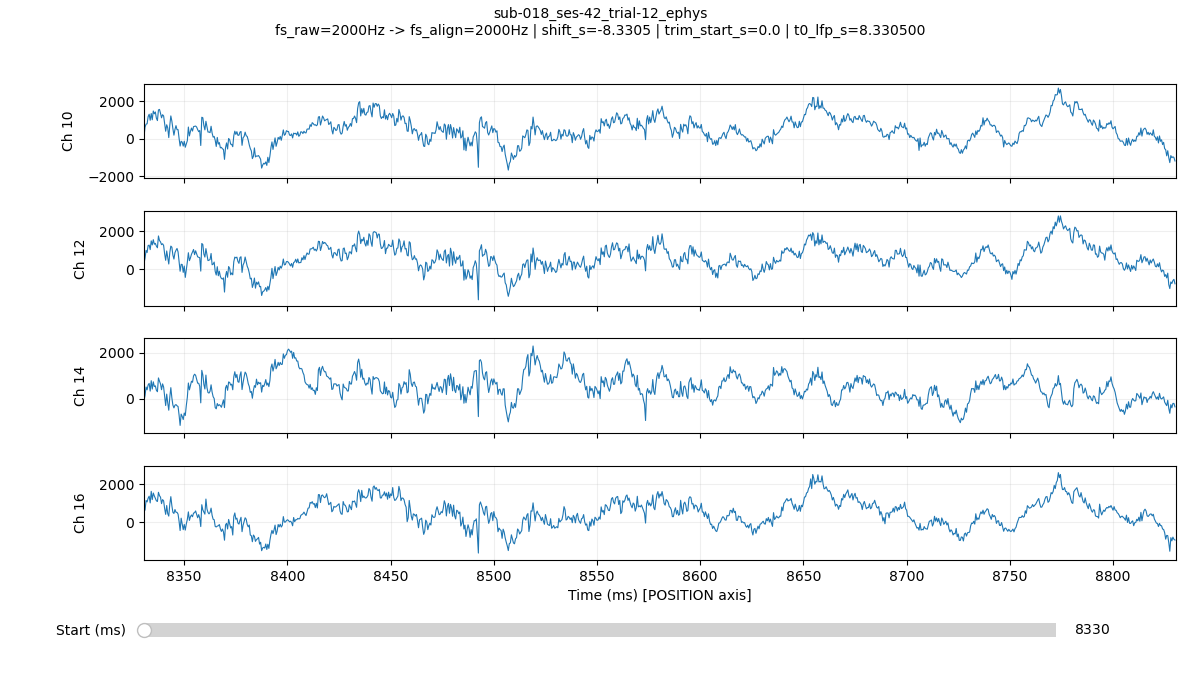

DONE


In [ ]:
# ============================================================
# Slider preview for a single meta_ephys row
# ============================================================

preview_row_idx = 1548  # set to desired row index in meta_ephys

# Ensure we use the test_data_loader DataLoader with ephys helpers
import util.test_data_loader as tdl
DataLoader = tdl.DataLoader

trial_id_raw = meta_ephys.loc[preview_row_idx, "ephys_trial_id"] if "ephys_trial_id" in meta_ephys.columns else None
trial_id_num = pd.to_numeric(trial_id_raw, errors="coerce")
if trial_id_raw is None or pd.isna(trial_id_num) or int(trial_id_num) == 0:
    raise ValueError("Selected row has ephys_trial_id = 0 or missing.")

dl = DataLoader(metadata_ses=meta_ephys.iloc[preview_row_idx])
if not hasattr(dl, "generate_ephys_filepath"):
    raise ValueError("DataLoader does not support generate_ephys_filepath for this row.")

position_path = dl.generate_filepath("position", "derivatives", "behav", "csv")
print("Position raw data path:", position_path)

position = dl.get_data("position")
if position is None or len(position) == 0:
    print(f"Empty position for row {preview_row_idx} -> {dl.generate_ephys_filepath()}")
else:
    out = sanity_slider_alignment_saved(
        dl=dl,
        fs_raw=2000.0,
        #channels=(25, 27, 29, 31),
        channels=(10, 12, 14, 16),
        window_s=0.5,
    )
    print("DONE")

rec_dir: /Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/rawdata/sub-016_id-AM/ses-08_date-20250801/ephys/sub-016_ses-08_trial-06_ephys
ttl_folder: /Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/rawdata/sub-016_id-AM/ses-08_date-20250801/ephys/sub-016_ses-08_trial-06_ephys/events/Acquisition_Board-100.Rhythm Data/TTL exists: True
cont_folder: /Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/rawdata/sub-016_id-AM/ses-08_date-20250801/ephys/sub-016_ses-08_trial-06_ephys/continuous/Acquisition_Board-100.Rhythm Data exists: True
TTL spans (raw timeline): 500
TTL spans (position timeline): 500


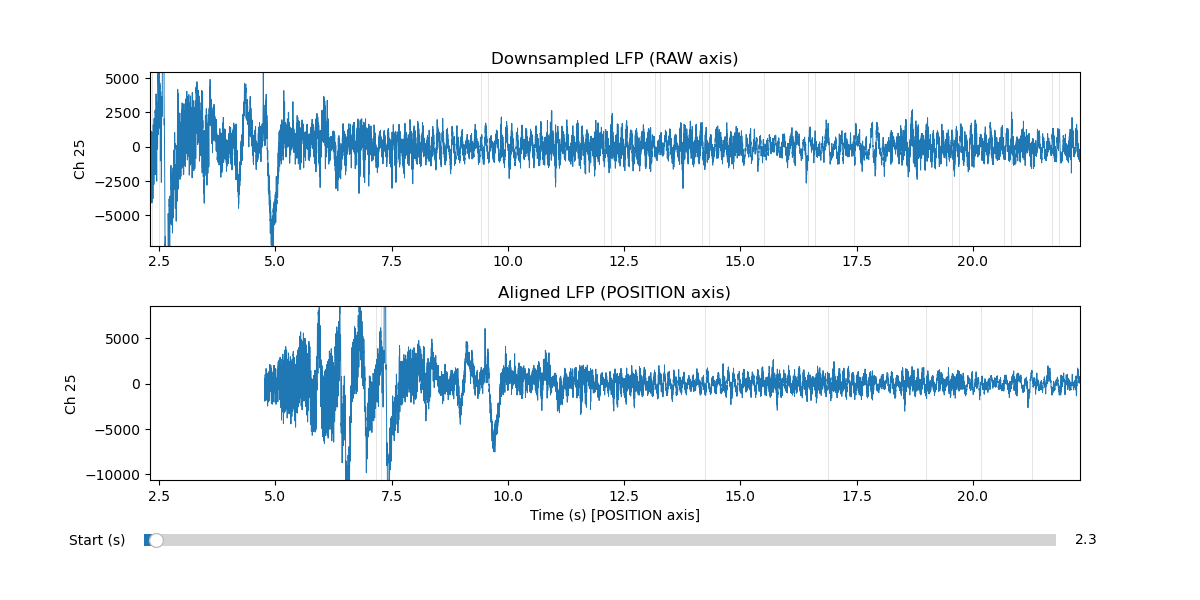

In [67]:

json_path = Path("/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/rawdata/sub-016_id-AM/ses-08_date-20250801/ephys/sub-016_ses-08_trial-06_ephys/sub-016_ses-08_trial-06_ephys_alignment.json")
info = json.loads(json_path.read_text())

# ------------------------------
# Load data + basic params
# ------------------------------
lfp = np.load(info["downsample_path"], mmap_mode="r")
lfp_aligned = None
if info.get("aligned_path"):
    try:
        lfp_aligned = np.load(info["aligned_path"], mmap_mode="r")
    except Exception:
        lfp_aligned = None

fs_ds = float(info["fs_ds"])
fs_raw = float(info["fs_raw"])
trim_start_s = float(info.get("trim_start_s") or 0.0)
shift_s = float(info.get("shift_s") or 0.0)

# ------------------------------
# TTL helpers
# ------------------------------
def _ttl_paths(info):
    rec_dir = Path(info["continuous_dat"]).parents[2]
    ttl_folder = rec_dir / "events/Acquisition_Board-100.Rhythm Data/TTL"
    cont_folder = rec_dir / "continuous/Acquisition_Board-100.Rhythm Data"
    return rec_dir, ttl_folder, cont_folder

def _load_ttl_spans(ttl_folder, cont_folder, fs_raw, shift_s):
    ttl_files_ok = (ttl_folder / "sample_numbers.npy").is_file() and (ttl_folder / "states.npy").is_file()
    cont_file_ok = (cont_folder / "sample_numbers.npy").is_file()
    if not (ttl_files_ok and cont_file_ok):
        return [], []

    stim_samp = np.load(ttl_folder / "sample_numbers.npy")
    states = np.load(ttl_folder / "states.npy")
    cont0 = int(np.load(cont_folder / "sample_numbers.npy", mmap_mode="r")[0])
    start_idx = np.where(states == 1)[0]
    end_idx = np.where(states == -1)[0]
    n_pair = min(len(start_idx), len(end_idx))
    if n_pair == 0:
        return [], []

    pulses_raw = np.stack([stim_samp[start_idx[:n_pair]], stim_samp[end_idx[:n_pair]]], axis=1)
    pulses_raw = pulses_raw[pulses_raw[:, 1] > pulses_raw[:, 0]]
    pulses_idx = (pulses_raw - cont0).astype(np.int64)
    pulses_idx = pulses_idx[pulses_idx[:, 1] > 0]

    ttl_spans_raw = [(s / fs_raw, e / fs_raw) for s, e in pulses_idx]
    ttl_spans_raw = [(s, e) for s, e in ttl_spans_raw if e > 0]
    ttl_spans_pos = [(s / fs_raw - shift_s, e / fs_raw - shift_s) for s, e in pulses_idx]
    ttl_spans_pos = [(s, e) for s, e in ttl_spans_pos if e > 0]
    return ttl_spans_raw, ttl_spans_pos

def _slice_by_time(t0, n_samp, i0, i1, fs):
    idx0 = int(np.floor((i0 - t0) * fs))
    idx1 = int(np.ceil((i1 - t0) * fs))
    idx0 = max(0, min(idx0, n_samp))
    idx1 = max(0, min(idx1, n_samp))
    if idx1 <= idx0:
        idx1 = min(n_samp, idx0 + 1)
    return idx0, idx1

def _shade_ttl(ax, spans, i0, i1):
    for p in list(ax.patches):
        p.remove()
    for s, e in spans:
        if e <= i0 or s >= i1:
            continue
        ax.axvspan(max(s, i0), min(e, i1), color="0.6", alpha=0.25, lw=0, zorder=0)

# ------------------------------
# TTL paths + spans
# ------------------------------
rec_dir, ttl_folder, cont_folder = _ttl_paths(info)
print("rec_dir:", rec_dir)
print("ttl_folder:", ttl_folder, "exists:", ttl_folder.exists())
print("cont_folder:", cont_folder, "exists:", cont_folder.exists())

ttl_spans_raw, ttl_spans_pos = _load_ttl_spans(ttl_folder, cont_folder, fs_raw, shift_s)
print("TTL spans (raw timeline):", len(ttl_spans_raw))
print("TTL spans (position timeline):", len(ttl_spans_pos))

# ------------------------------
# Plot setup
# ------------------------------
ch = 25
window_s = 20.0

# Downsample timeline (raw LFP time, starts at 0)
n = lfp.shape[0]
t_ds = np.arange(n) / fs_ds
t0_ds = 0.0
max_start_ds = max(0.0, float(t_ds[-1]) - window_s)

# Aligned timeline (POSITION axis)
n_aligned = lfp_aligned.shape[0] if lfp_aligned is not None else 0
t0_al = trim_start_s - shift_s
t_aligned = t0_al + (np.arange(n_aligned) / fs_ds) if n_aligned else np.array([])

t_start_min = 0.0
t_start_max = max_start_ds
init_start = 0.0
if ttl_spans_raw:
    init_start = max(t_start_min, min(float(min(s for s, _ in ttl_spans_raw)), t_start_max))

fig, (ax_ds, ax_al) = plt.subplots(2, 1, figsize=(12, 6), sharex=False)
plt.subplots_adjust(bottom=0.20, hspace=0.35)

ax_sl = fig.add_axes([0.12, 0.08, 0.76, 0.04])
sld = Slider(ax_sl, "Start (s)", t_start_min, t_start_max, valinit=init_start)
fig._slider = sld  # prevent GC

line_ds, = ax_ds.plot([], [], lw=0.7)
line_al, = ax_al.plot([], [], lw=0.7)
ax_ds.set_ylabel(f"Ch {ch}")
ax_ds.set_title("Downsampled LFP (RAW axis)")
ax_al.set_ylabel(f"Ch {ch}")
ax_al.set_xlabel("Time (s) [POSITION axis]")
ax_al.set_title("Aligned LFP (POSITION axis)")

def render(start_s):
    i0 = float(start_s)
    i1 = float(start_s + window_s)

    # Downsample (raw timeline)
    idx0, idx1 = _slice_by_time(t0_ds, n, i0, i1, fs_ds)
    tt = t_ds[idx0:idx1]
    yy = np.asarray(lfp[idx0:idx1, ch], dtype=float)
    line_ds.set_data(tt, yy)
    ax_ds.set_xlim(i0, i1)
    if yy.size:
        lo, hi = np.percentile(yy, [1, 99])
        pad = 0.25 * (hi - lo + 1e-9)
        ax_ds.set_ylim(lo - pad, hi + pad)
    else:
        ax_ds.set_ylim(-1, 1)
    _shade_ttl(ax_ds, ttl_spans_raw, i0, i1)

    # Aligned (POSITION timeline)
    if n_aligned:
        idx0a, idx1a = _slice_by_time(t0_al, n_aligned, i0, i1, fs_ds)
        tt_a = t_aligned[idx0a:idx1a]
        yy_a = np.asarray(lfp_aligned[idx0a:idx1a, ch], dtype=float)
        line_al.set_data(tt_a, yy_a)
        ax_al.set_xlim(i0, i1)
        if yy_a.size:
            lo, hi = np.percentile(yy_a, [1, 99])
            pad = 0.25 * (hi - lo + 1e-9)
            ax_al.set_ylim(lo - pad, hi + pad)
        else:
            ax_al.set_ylim(-1, 1)
        _shade_ttl(ax_al, ttl_spans_pos, i0, i1)
    else:
        line_al.set_data([], [])
        ax_al.set_xlim(i0, i1)
        ax_al.set_ylim(-1, 1)
        ax_al.text(0.5, 0.5, "No aligned LFP found", transform=ax_al.transAxes, ha="center", va="center", color="0.4")

    fig.canvas.draw_idle()

sld.on_changed(lambda v: render(sld.val))
render(init_start)
plt.show()

In [30]:
# ============================================================
# Example run to check individual rows/trials (edit these paths)
# ============================================================
base_dir = Path("/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/rawdata/sub-017_id-AN/ses-44_date-20251008/ephys")

rec = base_dir / "sub-017_ses-44_trial-18_ephys"

continuous_dat = rec / "continuous/Acquisition_Board-100.Rhythm Data/continuous.dat"

# MUST be the same acquisition stream folder for cont0 alignment
ttl_folder  = rec / "events/Acquisition_Board-100.Rhythm Data/TTL"
cont_folder = rec / "continuous/Acquisition_Board-100.Rhythm Data"

pos_csv = "/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-017_id-AN/ses-44_date-20251008/behav/sub-017_ses-44_trial-08_data-position.csv"

out = sanity_slider_alignment(
    continuous_dat_path=continuous_dat,
    fs_raw=2000.0,
    fs_plot=1000.0,
    ds_cache_dir=base_dir / "downsample_cache",
    force_rebuild_ds=False
,
    ttl_folder=ttl_folder,
    cont_folder=cont_folder,
    pos_csv_path=pos_csv
,
    channels=(25, 27, 29, 31),
    window_s=20.0
,
    pos_first_window_s=20.0,
    pos_min_detected_run_s=3.0
,
)

print("DONE")
print("Downsample cache:", out["ds_path"])
print("ratio:", out["ratio"])
print("shift_s:", out["shift_s"])
print("trial_start_lfp_s:", out["trial_start_lfp_s"])
print("TTL pulses:", len(out["ttl_spans"]))
print("inside_roi dots:", len(out["inside_idx_lfp"]))

Position file path: /Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-017_id-AN/ses-45_date-20251009/behav/sub-017_ses-45_trial-02_data-position.csv
Preprocessed position: None
Raw position: 5449 rows
timestamp range (ms): 57.0 -> 182060.0
monotonic increasing: True
first detected run start_idx: None
max detected run in first 20s (ms): 5595.0
rows in 11559-12059 ms window: 14
     timestamp  smooth_trans_x  smooth_trans_y  inside_roi
347      11563           -1.00           -1.00       False
348      11599           -1.00           -1.00       False
349      11666           -1.00           -1.00       False
350      11676           -1.00           -1.00       False
351      11730           -1.00           -1.00       False
352      11809           39.78           97.75       False
353      11830           39.75           97.70       False
354      11845           39.70           97.60       False
355      11861           39.66           97.56 

In [14]:
metadata = util.load_metadata()
dl = DataLoader(metadata.iloc[180])
position = dl.get_data('position')
cheeseboardMap = util.load_cheeseboard_map()
triggerLoc = dl.get_data('triggerLoc')
img = dl.get_data('trace')

In [15]:
dl.id, dl.ses_dir

('C', 'ses-08_date-20241007')

Text(0.5, 1.0, 'Animal Trajectory with Well Locations')

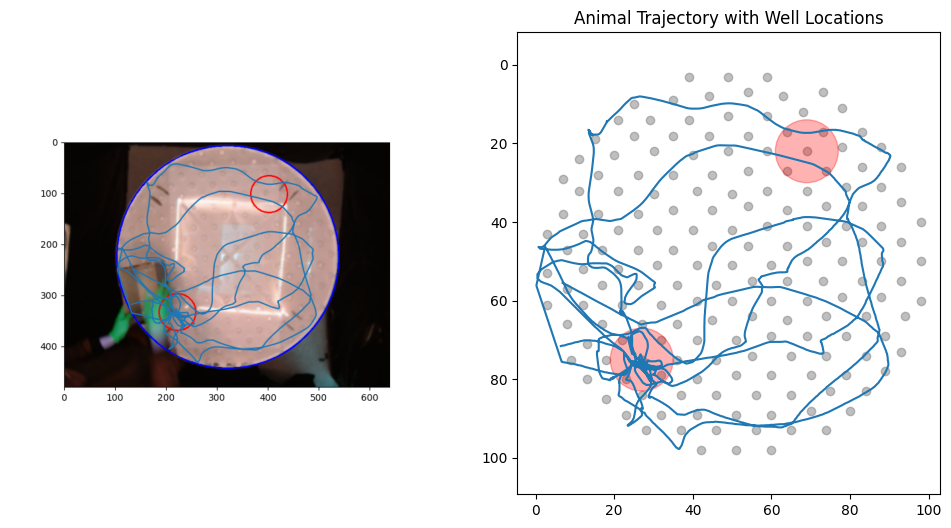

In [19]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1,2,figsize=(12,6), width_ratios=(1, 1))
axes[0].imshow(img)
axes[0].axis('off')

axes[1].plot(position['x'].values, position['y'].values)
axes[1].scatter(cheeseboardMap['x'].values, cheeseboardMap['y'].values, alpha=0.5, color='gray')
for i in range(len(triggerLoc)):
    x = triggerLoc['x'][i]
    y = triggerLoc['y'][i]
    circle = plt.Circle((x, y), 8, color='r', fill=True, linestyle='-', alpha=0.3)
    axes[1].add_artist(circle)

    # Equalize axis scales
axes[1].axis('equal')
# axes[1].axis('off')
# Flip the y-axis to match the coordinate system
axes[1].invert_yaxis()
axes[1].set_title('Animal Trajectory with Well Locations')